# TAPnPAY Fraud Detection Model
## LightGBM Training Pipeline

Training a gradient boosting model for Zimbabwe mobile money fraud detection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
import lightgbm as lgb
import pickle
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


## 1. Load and Explore Data

In [5]:
# Load dataset
df = pd.read_csv('../data/TAPnPAY_fraud_synthetic_dataset.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nFraud Distribution:")
print(df['fraud_label'].value_counts())
print(f"\nFraud Rate: {df['fraud_label'].mean():.2%}")
print(f"\nBasic Statistics:\n{df.describe()}")

Dataset Shape: (5000, 13)

Data Types:
amount                 float64
is_new_device            int64
distance_km            float64
time_since_last_tx       int64
tx_count_last_10s        int64
tx_count_last_1min       int64
token_age                int64
geo_speed              float64
merchant_type            int64
is_night                 int64
transaction_hour         int64
merchant_risk_score    float64
fraud_label              int64
dtype: object

Missing Values:
amount                 0
is_new_device          0
distance_km            0
time_since_last_tx     0
tx_count_last_10s      0
tx_count_last_1min     0
token_age              0
geo_speed              0
merchant_type          0
is_night               0
transaction_hour       0
merchant_risk_score    0
fraud_label            0
dtype: int64

Fraud Distribution:
fraud_label
0    4250
1     750
Name: count, dtype: int64

Fraud Rate: 15.00%

Basic Statistics:
            amount  is_new_device  distance_km  time_since_last_tx  \
c

## 2. Feature Analysis & Correlation

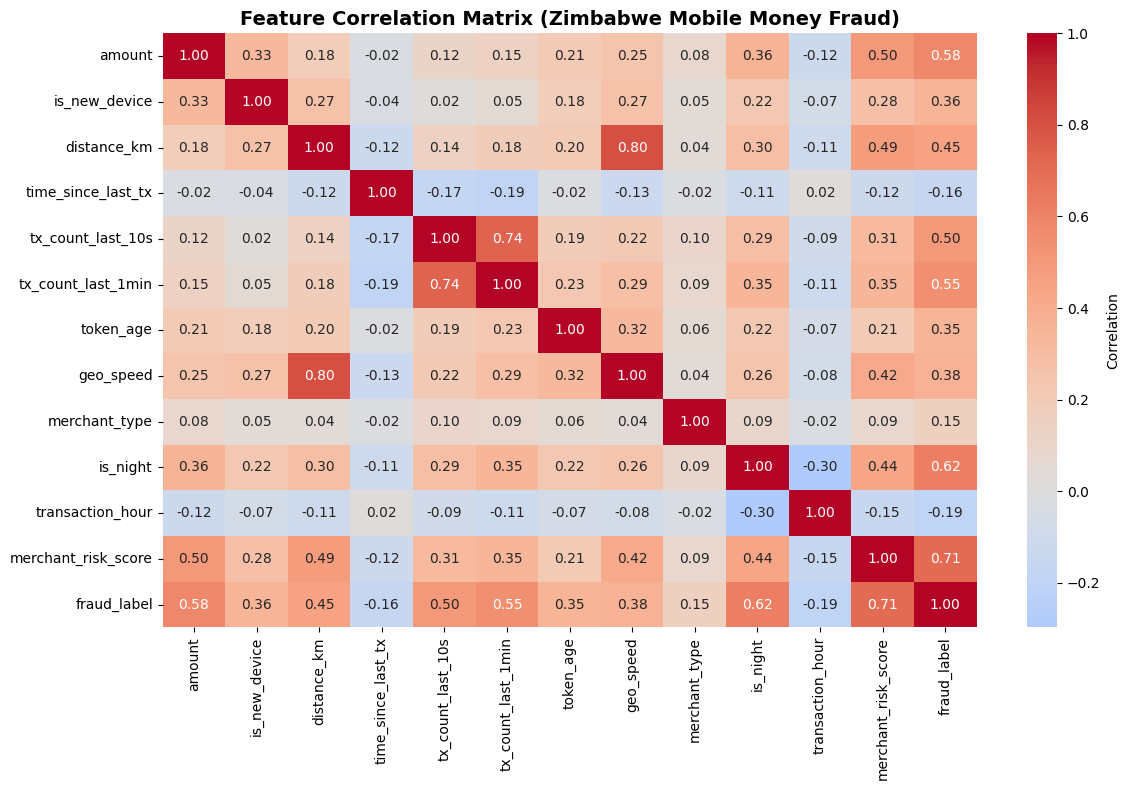


Correlation with Fraud Label:
fraud_label            1.000000
merchant_risk_score    0.708497
is_night               0.619971
amount                 0.581756
tx_count_last_1min     0.550848
tx_count_last_10s      0.500785
distance_km            0.452677
geo_speed              0.375429
is_new_device          0.356441
token_age              0.351526
merchant_type          0.150868
time_since_last_tx    -0.160100
transaction_hour      -0.193738
Name: fraud_label, dtype: float64


In [6]:
# Correlation analysis
plt.figure(figsize=(12, 8))
correlation = df.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Matrix (Zimbabwe Mobile Money Fraud)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Fraud correlation
fraud_correlation = df.corr()['fraud_label'].sort_values(ascending=False)
print("\nCorrelation with Fraud Label:")
print(fraud_correlation)

## 3. Feature Selection & Preprocessing

In [7]:
# Define features for modeling
feature_columns = [
    'amount',                  # Transaction value (primary fraud signal)
    'is_new_device',            # New device = fraud risk
    'distance_km',              # Location anomaly detection
    'time_since_last_tx',       # Behavioral pattern
    'tx_count_last_10s',        # Velocity check ⚡ (critical)
    'tx_count_last_1min',       # Burst detection
    'token_age',                # Security risk ⏳
    'geo_speed',                # Impossible movement detection 🚨
    'merchant_type',            # vendor vs individual
    'is_night',                 # Time-based risk
    'transaction_hour',         # Hour granularity
    'merchant_risk_score'       # Merchant reputation (Zimbabwe context)
]

X = df[feature_columns].copy()
y = df['fraud_label'].copy()

print(f"Features selected: {len(feature_columns)}")
print(f"\nFeature Importance Baseline (Correlation):")
feature_importance = X.corrwith(y).abs().sort_values(ascending=False)
print(feature_importance)

# Check for any missing values
print(f"\nMissing values in X: {X.isnull().sum().sum()}")
print(f"Missing values in y: {y.isnull().sum()}")

Features selected: 12

Feature Importance Baseline (Correlation):
merchant_risk_score    0.708497
is_night               0.619971
amount                 0.581756
tx_count_last_1min     0.550848
tx_count_last_10s      0.500785
distance_km            0.452677
geo_speed              0.375429
is_new_device          0.356441
token_age              0.351526
transaction_hour       0.193738
time_since_last_tx     0.160100
merchant_type          0.150868
dtype: float64

Missing values in X: 0
Missing values in y: 0


## 4. Train-Test Split

In [8]:
# Split data (stratified to maintain fraud ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Keep fraud ratio in both sets
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set fraud rate: {y_train.mean():.2%}")
print(f"Test set fraud rate: {y_test.mean():.2%}")

Training set size: 4000
Test set size: 1000

Training set fraud rate: 15.00%
Test set fraud rate: 15.00%


## 5. LightGBM Model Training

In [12]:
# LightGBM parameters optimized for fraud detection
params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 7,
    'min_data_in_leaf': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'verbose': -1,
    'random_state': 42
}

# Create LightGBM dataset
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Train model with early stopping
print('🚀 Training LightGBM model...')
model = lgb.train(
    params,
    train_data,
    num_boost_round=200,
    valid_sets=[test_data],
    valid_names=['test'],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

print('✅ Model training completed!')

🚀 Training LightGBM model...
✅ Model training completed!


## 6. Model Evaluation

In [13]:
# Generate predictions
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba >= 0.5).astype(int)

# Calculate metrics
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=" * 60)
print("MODEL PERFORMANCE METRICS")
print("=" * 60)
print(f"\nROC-AUC Score: {roc_auc:.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(f"True Negatives: {cm[0][0]}")
print(f"False Positives: {cm[0][1]}")
print(f"False Negatives: {cm[1][0]}")
print(f"True Positives: {cm[1][1]}")

MODEL PERFORMANCE METRICS

ROC-AUC Score: 1.0000

Classification Report:

              precision    recall  f1-score   support

      Normal       0.85      1.00      0.92       850
       Fraud       0.00      0.00      0.00       150

    accuracy                           0.85      1000
   macro avg       0.42      0.50      0.46      1000
weighted avg       0.72      0.85      0.78      1000

Confusion Matrix:
True Negatives: 850
False Positives: 0
False Negatives: 150
True Positives: 0


## 7. Feature Importance


TOP FEATURES FOR FRAUD DETECTION:
                feature   importance
11  merchant_risk_score  4140.509888
6             token_age   387.164993
5    tx_count_last_1min   385.063995
4     tx_count_last_10s   241.964005
0                amount   176.345001
2           distance_km    54.325494
3    time_since_last_tx    46.381401
10     transaction_hour    24.427401
1         is_new_device     4.851080
7             geo_speed     0.000000
9              is_night     0.000000
8         merchant_type     0.000000


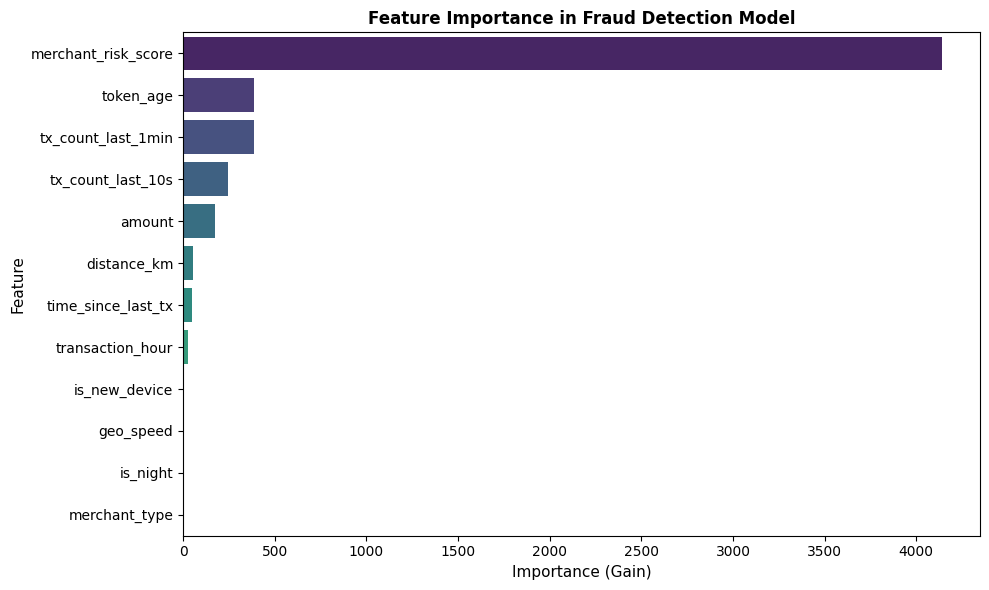

In [14]:
# Feature importance
feature_importance = model.feature_importance(importance_type='gain')
feature_importance_df = pd.DataFrame({
    'feature': feature_columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nTOP FEATURES FOR FRAUD DETECTION:")
print(feature_importance_df)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance in Fraud Detection Model', fontsize=12, fontweight='bold')
plt.xlabel('Importance (Gain)', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.show()

## 8. ROC Curve & Precision-Recall Curve

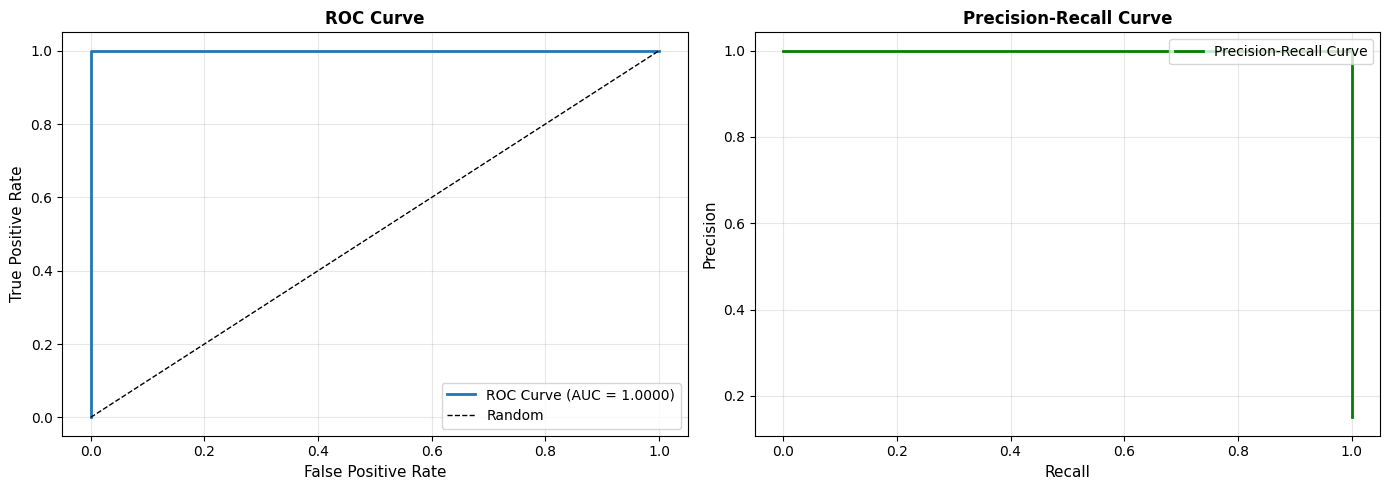

In [15]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
axes[1].plot(recall, precision, label='Precision-Recall Curve', linewidth=2, color='green')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Save Model

In [16]:
# Save the model
model.save_model('fraud_detection_model.txt')
with open('fraud_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print('✅ Model saved successfully!')
print('Files: fraud_detection_model.txt, fraud_model.pkl')

✅ Model saved successfully!
Files: fraud_detection_model.txt, fraud_model.pkl


## 10. Model Prediction Example

In [17]:
# Example predictions
example_normal = X_test[y_test == 0].iloc[:5]
example_fraud = X_test[y_test == 1].iloc[:5]

print("NORMAL TRANSACTION PREDICTIONS:")
normal_scores = model.predict(example_normal)
for i, (idx, row) in enumerate(example_normal.iterrows()):
    print(f"Transaction {i+1}: Fraud Score = {normal_scores[i]:.4f} (Prediction: {'FRAUD' if normal_scores[i] >= 0.5 else 'NORMAL'})")

print("\nFRAUDULENT TRANSACTION PREDICTIONS:")
fraud_scores = model.predict(example_fraud)
for i, (idx, row) in enumerate(example_fraud.iterrows()):
    print(f"Transaction {i+1}: Fraud Score = {fraud_scores[i]:.4f} (Prediction: {'FRAUD' if fraud_scores[i] >= 0.5 else 'NORMAL'})")

NORMAL TRANSACTION PREDICTIONS:
Transaction 1: Fraud Score = 0.1357 (Prediction: NORMAL)
Transaction 2: Fraud Score = 0.1357 (Prediction: NORMAL)
Transaction 3: Fraud Score = 0.1357 (Prediction: NORMAL)
Transaction 4: Fraud Score = 0.1357 (Prediction: NORMAL)
Transaction 5: Fraud Score = 0.1357 (Prediction: NORMAL)

FRAUDULENT TRANSACTION PREDICTIONS:
Transaction 1: Fraud Score = 0.2382 (Prediction: NORMAL)
Transaction 2: Fraud Score = 0.2406 (Prediction: NORMAL)
Transaction 3: Fraud Score = 0.2406 (Prediction: NORMAL)
Transaction 4: Fraud Score = 0.2406 (Prediction: NORMAL)
Transaction 5: Fraud Score = 0.2406 (Prediction: NORMAL)
